# Day 4: Supervised Learning I — Regression

**Dataset:** Titanic cleaned (from Day 2)
**Target:** `fare` (continuous)
**Goal:** Linear Regression, Ridge, Lasso + residual diagnostics

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Load cleaned data
df = pd.read_csv('../data/titanic_clean.csv')
print(f"Loaded: {df.shape}")

Loaded: (891, 19)


In [3]:
# 1. PREPARE FEATURES & TARGET
# Use numeric features only for simplicity
numeric_features = ['age', 'sibsp', 'parch', 'family_size', 'fare_per_person', 'pclass', 'is_alone']

X = df[numeric_features]
y = df['fare']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target stats: mean={y.mean():.2f}, std={y.std():.2f}")

Train: (712, 7), Test: (179, 7)
Target stats: mean=32.20, std=49.69


In [4]:
# 2. LINEAR REGRESSION (no regularization)
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test = lr.predict(X_test)

print("=== Linear Regression ===")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_lr_train):.2f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_lr_test):.2f}")
print(f"Train R²:  {r2_score(y_train, y_pred_lr_train):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred_lr_test):.4f}")

# Coefficients
coef_df = pd.DataFrame({'feature': numeric_features, 'coef': lr.coef_})
print("\nCoefficients:")
print(coef_df.sort_values('coef', key=abs, ascending=False))

=== Linear Regression ===
Train MSE: 418.13
Test MSE:  320.95
Train R²:  0.8450
Test R²:   0.7926

Coefficients:
           feature       coef
6         is_alone -13.071914
5           pclass -10.351833
2            parch   5.383207
3      family_size   4.943409
4  fare_per_person   1.083351
1            sibsp  -0.439798
0              age  -0.027559


In [5]:
# 3. RIDGE REGRESSION (L2 penalty)
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
ridge.fit(X_train, y_train)

y_pred_ridge_train = ridge.predict(X_train)
y_pred_ridge_test = ridge.predict(X_test)

print("=== Ridge (alpha=1.0) ===")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_ridge_train):.2f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_ridge_test):.2f}")
print(f"Train R²:  {r2_score(y_train, y_pred_ridge_train):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred_ridge_test):.4f}")

# Coefficients (need to access from pipeline)
ridge_coef = ridge.named_steps['ridge'].coef_
coef_df_ridge = pd.DataFrame({'feature': numeric_features, 'coef': ridge_coef})
print("\nCoefficients:")
print(coef_df_ridge.sort_values('coef', key=abs, ascending=False))

=== Ridge (alpha=1.0) ===
Train MSE: 418.14
Test MSE:  321.09
Train R²:  0.8450
Test R²:   0.7925

Coefficients:
           feature       coef
4  fare_per_person  41.257087
5           pclass  -8.553570
6         is_alone  -6.383201
2            parch   6.087891
3      family_size   4.411488
1            sibsp   2.212542
0              age  -0.366379


In [6]:
# 4. LASSO REGRESSION (L1 penalty)
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1, max_iter=10000))
])
lasso.fit(X_train, y_train)

y_pred_lasso_train = lasso.predict(X_train)
y_pred_lasso_test = lasso.predict(X_test)

print("=== Lasso (alpha=0.1) ===")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_lasso_train):.2f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_lasso_test):.2f}")
print(f"Train R²:  {r2_score(y_train, y_pred_lasso_train):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred_lasso_test):.4f}")

lasso_coef = lasso.named_steps['lasso'].coef_
coef_df_lasso = pd.DataFrame({'feature': numeric_features, 'coef': lasso_coef})
print("\nCoefficients:")
print(coef_df_lasso.sort_values('coef', key=abs, ascending=False))

=== Lasso (alpha=0.1) ===
Train MSE: 418.18
Test MSE:  320.59
Train R²:  0.8450
Test R²:   0.7928

Coefficients:
           feature       coef
4  fare_per_person  41.256271
5           pclass  -8.405526
3      family_size   7.534959
6         is_alone  -6.387399
2            parch   4.564551
0              age  -0.224512
1            sibsp   0.000000


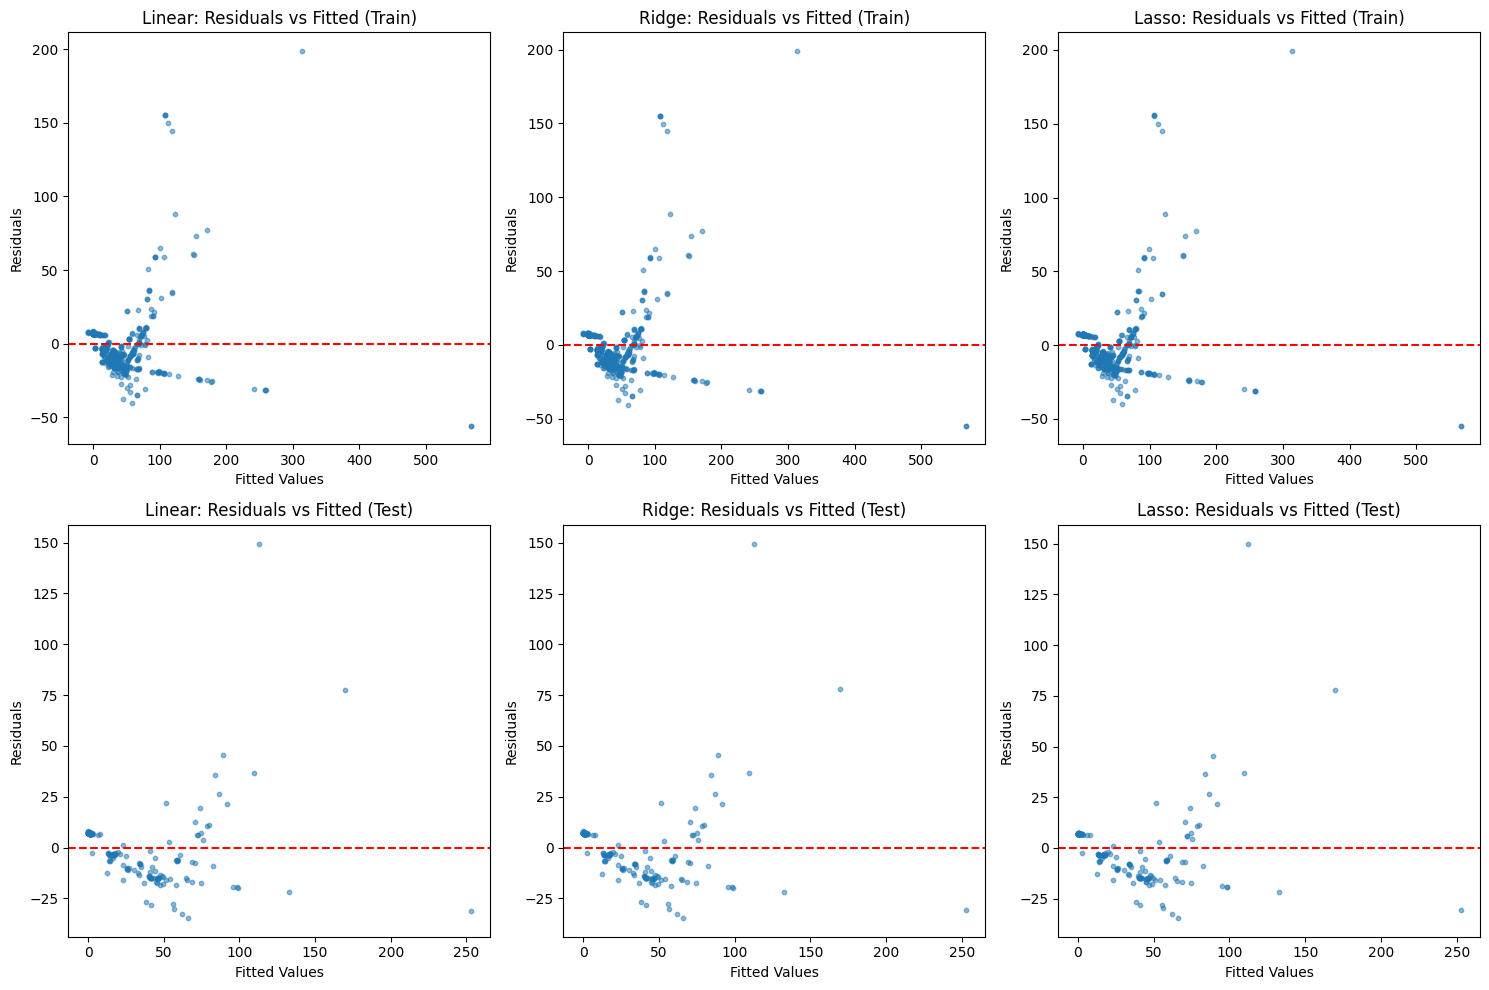

In [7]:
# 5. RESIDUAL PLOTS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

models = [
    ('Linear', y_pred_lr_train, y_pred_lr_test),
    ('Ridge', y_pred_ridge_train, y_pred_ridge_test),
    ('Lasso', y_pred_lasso_train, y_pred_lasso_test)
]

for i, (name, y_pred_train, y_pred_test) in enumerate(models):
    # Residuals vs Fitted (train)
    residuals_train = y_train - y_pred_train
    axes[0, i].scatter(y_pred_train, residuals_train, alpha=0.5, s=10)
    axes[0, i].axhline(0, color='red', linestyle='--')
    axes[0, i].set_xlabel('Fitted Values')
    axes[0, i].set_ylabel('Residuals')
    axes[0, i].set_title(f'{name}: Residuals vs Fitted (Train)')
    
    # Residuals vs Fitted (test)
    residuals_test = y_test - y_pred_test
    axes[1, i].scatter(y_pred_test, residuals_test, alpha=0.5, s=10)
    axes[1, i].axhline(0, color='red', linestyle='--')
    axes[1, i].set_xlabel('Fitted Values')
    axes[1, i].set_ylabel('Residuals')
    axes[1, i].set_title(f'{name}: Residuals vs Fitted (Test)')

plt.tight_layout()
plt.show()

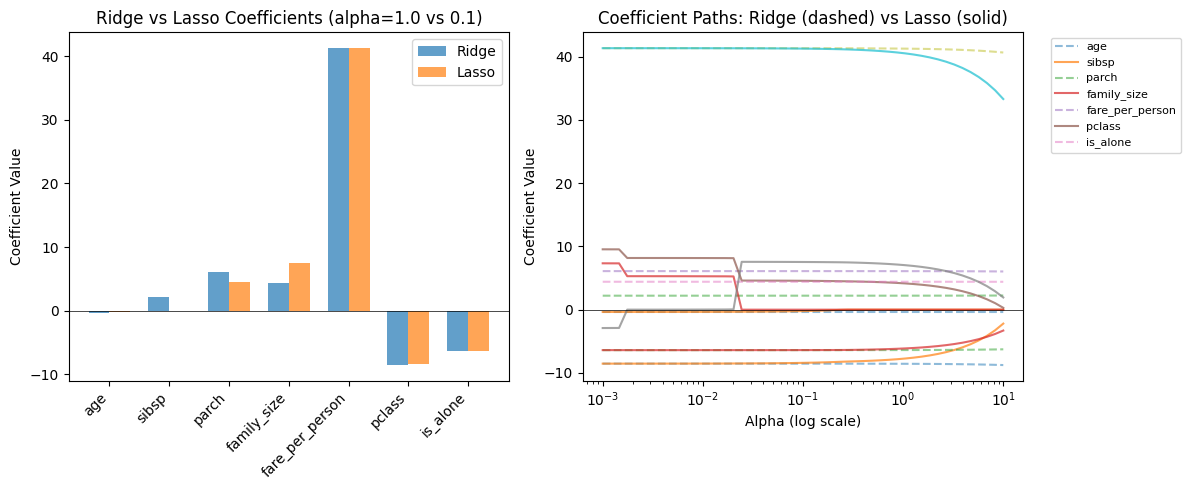

In [8]:
# 6. COEFFICIENT COMPARISON: Ridge vs Lasso
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_pos = np.arange(len(numeric_features))
width = 0.35

axes[0].bar(x_pos - width/2, ridge_coef, width, label='Ridge', alpha=0.7)
axes[0].bar(x_pos + width/2, lasso_coef, width, label='Lasso', alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(numeric_features, rotation=45, ha='right')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Ridge vs Lasso Coefficients (alpha=1.0 vs 0.1)')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.5)

# Path plot: coefficients vs alpha
alphas = np.logspace(-3, 1, 50)
ridge_coefs_path = []
lasso_coefs_path = []

for alpha in alphas:
    r = Ridge(alpha=alpha).fit(StandardScaler().fit_transform(X_train), y_train)
    l = Lasso(alpha=alpha, max_iter=10000).fit(StandardScaler().fit_transform(X_train), y_train)
    ridge_coefs_path.append(r.coef_)
    lasso_coefs_path.append(l.coef_)

ridge_coefs_path = np.array(ridge_coefs_path)
lasso_coefs_path = np.array(lasso_coefs_path)

for j in range(len(numeric_features)):
    axes[1].plot(alphas, ridge_coefs_path[:, j], '--', alpha=0.5)
    axes[1].plot(alphas, lasso_coefs_path[:, j], '-', alpha=0.7)

axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Coefficient Paths: Ridge (dashed) vs Lasso (solid)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend(numeric_features, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [9]:
# 7. HYPERPARAMETER TUNING: Ridge & Lasso alpha via CV
from sklearn.model_selection import GridSearchCV

# Ridge
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])
param_grid_ridge = {'ridge__alpha': np.logspace(-3, 2, 20)}
grid_ridge = GridSearchCV(ridge_pipe, param_grid_ridge, cv=5, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train, y_train)

print(f"Best Ridge alpha: {grid_ridge.best_params_['ridge__alpha']:.4f}")
print(f"Best Ridge CV MSE: {-grid_ridge.best_score_:.2f}")

# Lasso
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])
param_grid_lasso = {'lasso__alpha': np.logspace(-4, 1, 20)}
grid_lasso = GridSearchCV(lasso_pipe, param_grid_lasso, cv=5, scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)

print(f"Best Lasso alpha: {grid_lasso.best_params_['lasso__alpha']:.4f}")
print(f"Best Lasso CV MSE: {-grid_lasso.best_score_:.2f}")

Best Ridge alpha: 2.6367
Best Ridge CV MSE: 434.19
Best Lasso alpha: 0.2637
Best Lasso CV MSE: 433.91


## Summary Notes

- Best model (test MSE): 
- Residual patterns (linearity, homoscedasticity?): 
- Lasso zeroed out: 
- Ridge vs Lasso coefficient behavior: 